# CPS ASEC 2025 — Data Cleaning, EDA & Statistical Analysis

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RAW_DATA_PATH = "../data/cps_00003.csv"
CLEANED_DATA_PATH = "../data/cps_cleaned.csv"


## Load raw data

In [6]:
raw_df = pd.read_csv(RAW_DATA_PATH)
print(f"Raw sample size: {len(raw_df):,} rows, {raw_df.shape[1]} columns")
raw_df.head()


Raw sample size: 111,796 rows, 32 columns


,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,STATEFIP,PERNUM,CPSIDP,CPSIDV,...,INCWAGE,LABOR_FORCE,EMPLOYED,UNEMPLOYED,NILF,SEX_LABEL,MARST_LABEL,EDUC_CAT,CLASS_LABEL,LOG_INCWAGE
0,2025,1,3,20240200364300,1,"1,412.29",23,1,20240200364301,202402003643011,...,0,0,0,0,1,Male,Divorced,Some College,Other/Unknown,NaN
1,2025,1,3,20240200364300,1,"1,412.29",23,2,20240200364302,202402003643021,...,0,0,0,0,1,Female,Divorced,Some College,Other/Unknown,NaN
2,2025,9,3,20240100364300,1,"1,485.41",23,1,20240100364301,202401003643011,...,0,0,0,0,1,Male,Divorced,High School or Less,Other/Unknown,NaN
3,2025,10,3,20240100360600,1,"1,488.84",23,1,20240100360601,202401003606011,...,0,0,0,0,1,Female,Never married,High School or Less,Other/Unknown,NaN
4,2025,12,3,20250101603800,1,"1,518.33",23,1,20250101603801,202501016038011,...,130000,1,1,0,0,Female,Married spouse present,Bachelor's,Private wage/salary,11.78


In [7]:
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111796 entries, 0 to 111795
Data columns (total 32 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   YEAR         111796 non-null  int64  
 1   SERIAL       111796 non-null  int64  
 2   MONTH        111796 non-null  int64  
 3   CPSID        111796 non-null  int64  
 4   ASECFLAG     111796 non-null  int64  
 5   ASECWTH      111796 non-null  float64
 6   STATEFIP     111796 non-null  int64  
 7   PERNUM       111796 non-null  int64  
 8   CPSIDP       111796 non-null  int64  
 9   CPSIDV       111796 non-null  int64  
 10  ASECWT       111796 non-null  float64
 11  AGE          111796 non-null  int64  
 12  SEX          111796 non-null  int64  
 13  RACE         111796 non-null  int64  
 14  MARST        111796 non-null  int64  
 15  EMPSTAT      111796 non-null  int64  
 16  OCC          111796 non-null  int64  
 17  IND          111796 non-null  int64  
 18  CLASSWKR     111796 non-

In [8]:
# missing values check
missing = raw_df.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) else "No missing values in raw columns.")


LOG_INCWAGE    43896
dtype: int64


## Filter sample
Working-age (16+), civilian, ASEC-eligible population.

In [9]:
df = raw_df.copy()
print(f"Original: {len(df):,}")

df = df[df["AGE"] >= 16]
print(f"Age >= 16: {len(df):,}")

df = df[df["EMPSTAT"] != 1]          # drop Armed Forces
print(f"Drop Armed Forces: {len(df):,}")

df = df[df["EMPSTAT"] != 0]          # drop Not In Universe
print(f"Drop NIU: {len(df):,}")

df = df[df["ASECFLAG"] == 1]         # keep ASEC records only
print(f"ASEC only: {len(df):,}")

df = df.copy()


Original: 111,796
Age >= 16: 111,796
Drop Armed Forces: 111,796
Drop NIU: 111,796
ASEC only: 111,796


## Feature engineering
Labor-force status flags, readable category labels, log wage.

In [10]:
# labor force status
employed_codes = [10, 12]
unemployed_codes = [20, 21, 22]
nilf_codes = [30, 31, 32, 33, 34, 35, 36]

df["LABOR_FORCE"] = df["EMPSTAT"].isin(employed_codes + unemployed_codes).astype(int)
df["EMPLOYED"] = df["EMPSTAT"].isin(employed_codes).astype(int)
df["UNEMPLOYED"] = df["EMPSTAT"].isin(unemployed_codes).astype(int)
df["NILF"] = df["EMPSTAT"].isin(nilf_codes).astype(int)


In [11]:
# category labels
df["SEX_LABEL"] = df["SEX"].map({1: "Male", 2: "Female"})

marst_map = {1: "Married spouse present", 2: "Married spouse absent", 3: "Separated",
             4: "Divorced", 5: "Widowed", 6: "Never married"}
df["MARST_LABEL"] = df["MARST"].map(marst_map)

def educ_cat(e):
    if e <= 73: return "High School or Less"
    if 80 <= e <= 92: return "Some College"
    if e == 111: return "Bachelor's"
    if 123 <= e <= 125: return "Advanced Degree"
    return "Other"

df["EDUC_CAT"] = df["EDUC"].apply(educ_cat)

class_map = {10: "Self-employed", 13: "Self-employed not inc", 14: "Self-employed inc",
             21: "Private wage/salary", 22: "Private for profit", 23: "Private nonprofit",
             24: "Government", 25: "Federal", 27: "State", 28: "Local", 29: "Unpaid family"}
df["CLASS_LABEL"] = df["CLASSWKR"].map(class_map).fillna("Other/Unknown")

df[["SEX_LABEL", "MARST_LABEL", "EDUC_CAT", "CLASS_LABEL"]].head()


,SEX_LABEL,MARST_LABEL,EDUC_CAT,CLASS_LABEL
0,Male,Divorced,Some College,Other/Unknown
1,Female,Divorced,Some College,Other/Unknown
2,Male,Divorced,High School or Less,Other/Unknown
3,Female,Never married,High School or Less,Other/Unknown
4,Female,Married spouse present,Bachelor's,Private wage/salary


In [12]:
# log wage (0 wage -> NaN)
df["LOG_INCWAGE"] = np.log(df["INCWAGE"].replace(0, np.nan))
df[["INCWAGE", "LOG_INCWAGE"]].describe()


,INCWAGE,LOG_INCWAGE
count,"111,796.00","67,900.00"
mean,"44,090.73",10.70
std,"81,034.26",1.13
min,0.00,0.00
25%,0.00,10.30
50%,"20,000.00",10.84
75%,"60,000.00",11.36
max,"2,099,999.00",14.56


## Wage outliers (IQR rule)
Just a check — outliers are kept, not removed.

In [13]:
wage_pos = df[df["INCWAGE"] > 0]["INCWAGE"]
q1, q3 = wage_pos.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((wage_pos < low) | (wage_pos > high)).sum()

print(f"Q1=${q1:,.0f}  Q3=${q3:,.0f}  IQR=${iqr:,.0f}  upper bound=${high:,.0f}")
print(f"Outliers: {n_out:,} ({n_out / len(wage_pos) * 100:.1f}% of positive-wage workers)")


Q1=$29,600  Q3=$86,000  IQR=$56,400  upper bound=$170,600
Outliers: 4,230 (6.2% of positive-wage workers)


In [14]:
df.to_csv(CLEANED_DATA_PATH, index=False)
print(f"Saved cleaned data: {len(df):,} rows, {df.shape[1]} columns -> {CLEANED_DATA_PATH}")


Saved cleaned data: 111,796 rows, 32 columns -> /content/drive/MyDrive/Wage_Labour_Market_analysis/Data/cps_cleaned.csv


## EDA: demographics

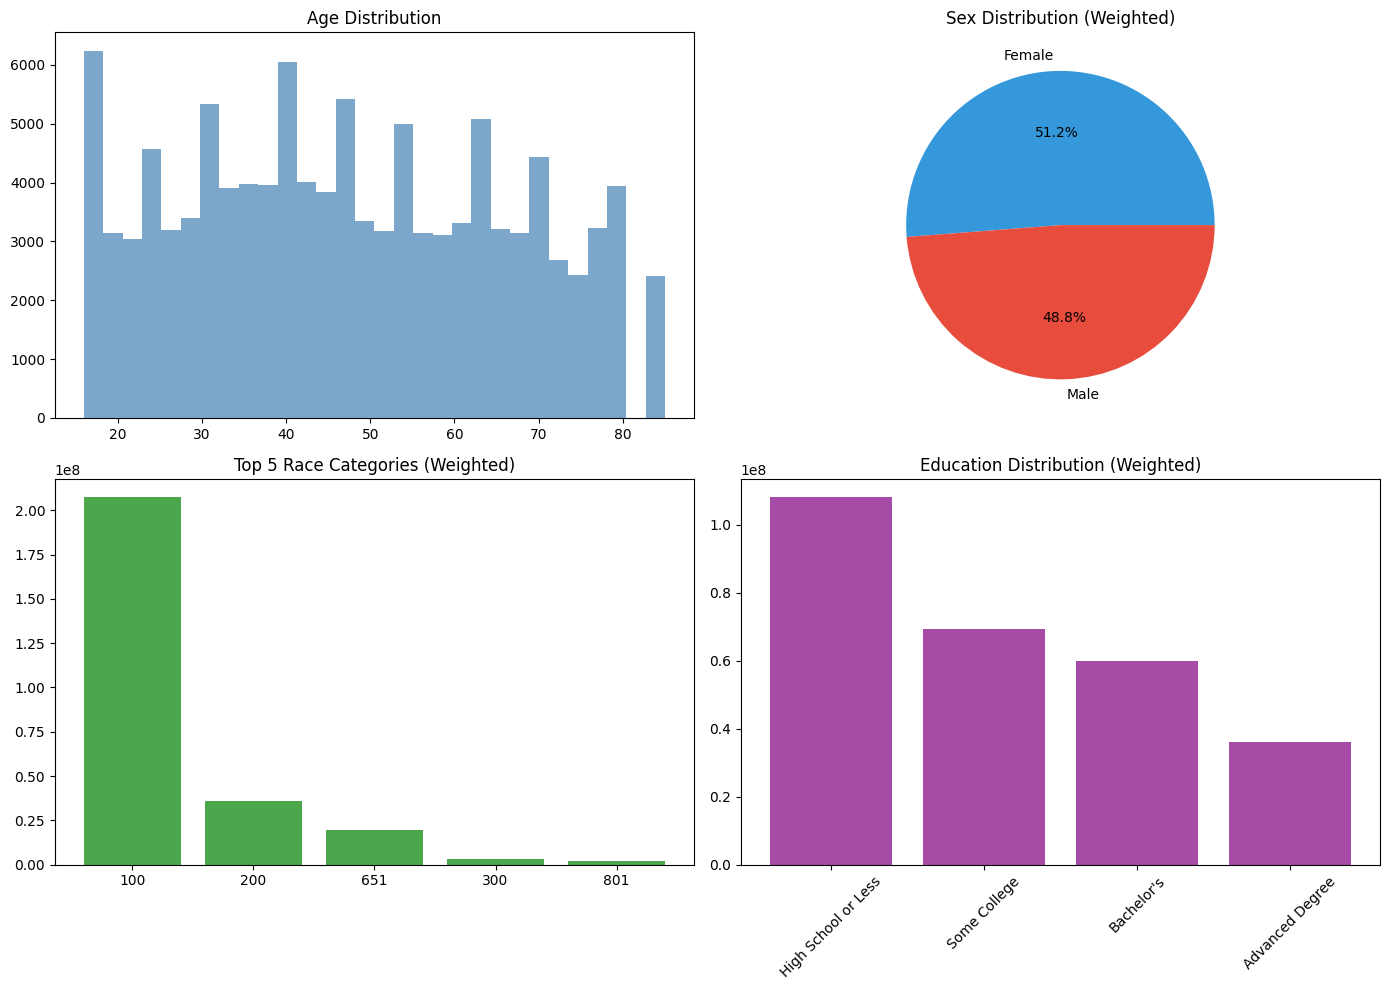

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["AGE"], bins=30, alpha=0.7, color="steelblue")
axes[0, 0].set_title("Age Distribution")

sex_w = df.groupby("SEX_LABEL")["ASECWT"].sum()
axes[0, 1].pie(sex_w, labels=sex_w.index, autopct="%1.1f%%", colors=["#3498db", "#e74c3c"])
axes[0, 1].set_title("Sex Distribution (Weighted)")

race_w = df.groupby("RACE")["ASECWT"].sum().sort_values(ascending=False).head(5)
axes[1, 0].bar(race_w.index.astype(str), race_w.values, color="green", alpha=0.7)
axes[1, 0].set_title("Top 5 Race Categories (Weighted)")

educ_w = df.groupby("EDUC_CAT")["ASECWT"].sum().sort_values(ascending=False)
axes[1, 1].bar(educ_w.index, educ_w.values, color="purple", alpha=0.7)
axes[1, 1].set_title("Education Distribution (Weighted)")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()


## Wages by education

In [20]:
edu_stats = df_ft.groupby("EDUC_CAT")["INCWAGE"].agg(["mean", "median", "count"]).round(0)
edu_stats["weighted_median"] = df_ft.groupby("EDUC_CAT").apply(lambda g: weighted_median(g["INCWAGE"], g["ASECWT"]))
edu_stats


/tmp/ipykernel_729/2044555925.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  edu_stats["weighted_median"] = df_ft.groupby("EDUC_CAT").apply(lambda g: weighted_median(g["INCWAGE"], g["ASECWT"]))


,mean,median,count,weighted_median
EDUC_CAT,,,,
Advanced Degree,"134,654.00","100,000.00",9238,100000
Bachelor's,"99,323.00","75,000.00",14100,75000
High School or Less,"54,929.00","44,000.00",16685,43000
Some College,"66,541.00","54,582.00",12860,54000


In [21]:
base = edu_stats.loc["High School or Less", "weighted_median"]
for lvl in edu_stats.index:
    print(f"{lvl}: {(edu_stats.loc[lvl, 'weighted_median'] - base) / base * 100:+.0f}% vs. High School or Less")


Advanced Degree: +133% vs. High School or Less
Bachelor's: +74% vs. High School or Less
High School or Less: +0% vs. High School or Less
Some College: +26% vs. High School or Less


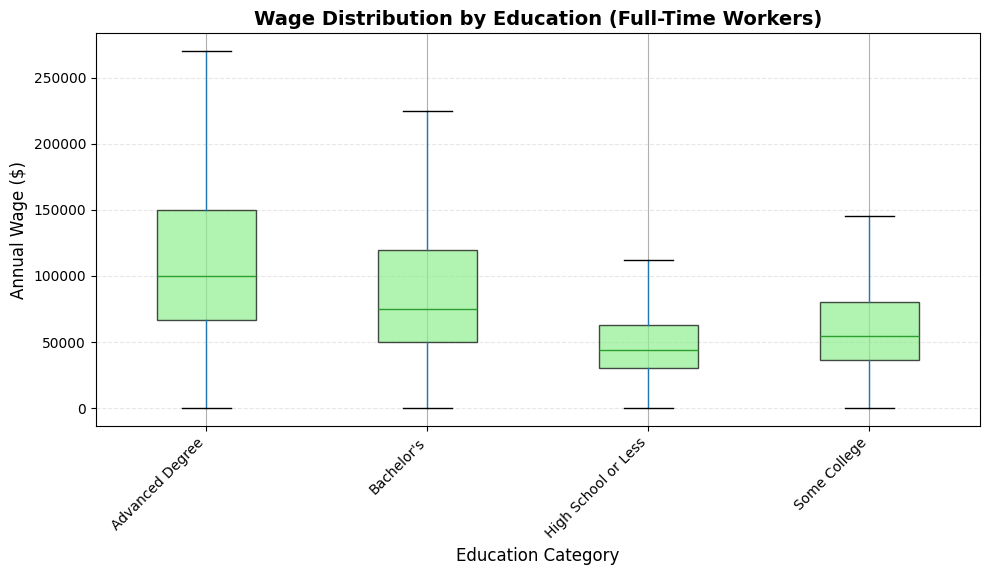

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

df_ft.boxplot(
    column="INCWAGE",
    by="EDUC_CAT",
    ax=ax,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', alpha=0.7)
)

ax.set_title("Wage Distribution by Education (Full-Time Workers)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Education Category", fontsize=12)
ax.set_ylabel("Annual Wage ($)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.suptitle("")
plt.tight_layout()
# plt.savefig('../figures/wage_by_education_clean.png', dpi=300, bbox_inches='tight')
plt.show()

## Wages by industry (top 10 by frequency)

In [23]:
top_ind = df_ft["IND"].value_counts().head(10).index
df_ind = df_ft[df_ft["IND"].isin(top_ind)]

ind_stats = df_ind.groupby("IND")["INCWAGE"].agg(["mean", "median", "count"]).round(0)
ind_stats.sort_values("median", ascending=False)


,mean,median,count
IND,,,
7380,"146,263.00","120,000.00",1433
6871,"111,009.00","79,950.00",764
9470,"91,721.00","78,370.00",1048
7870,"89,107.00","72,000.00",1341
8191,"93,291.00","70,000.00",2741
770,"76,592.00","60,000.00",4054
8090,"83,035.00","60,000.00",821
7860,"65,148.00","58,000.00",3561
5392,"55,774.00","40,000.00",935


/tmp/ipykernel_729/303756029.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ind['IND_NAME'] = df_ind['IND'].map(industry_names)


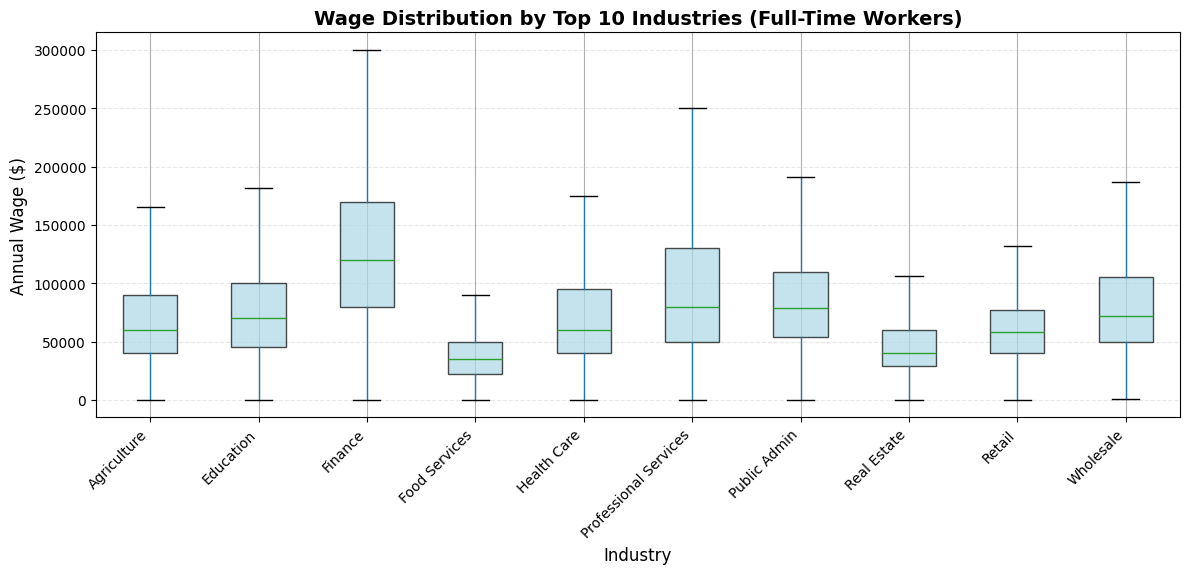

In [45]:
industry_names = {
    770: 'Agriculture',
    5392: 'Real Estate',
    6871: 'Professional Services',
    7380: 'Finance',
    7860: 'Retail',
    7870: 'Wholesale',
    8090: 'Health Care',
    8191: 'Education',
    8680: 'Food Services',
    9470: 'Public Admin'
}

df_ind['IND_NAME'] = df_ind['IND'].map(industry_names)

fig, ax = plt.subplots(figsize=(12, 6))

df_ind.boxplot(
    column="INCWAGE",
    by="IND_NAME",
    ax=ax,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7)
)

ax.set_title("Wage Distribution by Top 10 Industries (Full-Time Workers)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Industry", fontsize=12)
ax.set_ylabel("Annual Wage ($)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.suptitle("")
plt.tight_layout()
plt.show()

## Labor force participation & unemployment rate
Weighted with ASECWT.

In [25]:
total_w = df["ASECWT"].sum()
lf_w = df.loc[df["LABOR_FORCE"] == 1, "ASECWT"].sum()
unemp_w = df.loc[df["UNEMPLOYED"] == 1, "ASECWT"].sum()

lfpr = lf_w / total_w * 100
unemployment_rate = unemp_w / lf_w * 100

print(f"Labor force participation rate: {lfpr:.1f}%")
print(f"Unemployment rate: {unemployment_rate:.1f}%")


Labor force participation rate: 62.5%
Unemployment rate: 4.3%


## Gender wage gap — all positive-wage workers

In [ ]:
def weighted_median(v, w):
    v, w = v.values, w.values
    idx = np.argsort(v)
    v, w = v[idx], w[idx]
    return v[np.searchsorted(w.cumsum(), w.sum() / 2)]

df_wage = df[df["INCWAGE"] > 0].copy()
stats = df_wage.groupby("SEX_LABEL")["INCWAGE"].agg(["mean", "median", "count"])
print(stats)

male, female = stats.loc["Male"], stats.loc["Female"]
mean_gap = (male["mean"] - female["mean"]) / male["mean"] * 100
median_gap = (male["median"] - female["median"]) / male["median"] * 100

wmed_m = weighted_median(df_wage.loc[df_wage["SEX_LABEL"] == "Male", "INCWAGE"], df_wage.loc[df_wage["SEX_LABEL"] == "Male", "ASECWT"])
wmed_f = weighted_median(df_wage.loc[df_wage["SEX_LABEL"] == "Female", "INCWAGE"], df_wage.loc[df_wage["SEX_LABEL"] == "Female", "ASECWT"])
wmed_gap = (wmed_m - wmed_f) / wmed_m * 100

print(f"\nMean-based gap: {mean_gap:.1f}%")
print(f"Median-based gap: {median_gap:.1f}%")
print(f"Weighted-median gap: {wmed_gap:.1f}%")


               mean    median  count
SEX_LABEL                           
Female    59,962.50 45,000.00  32957
Male      84,508.58 60,000.00  34943

Mean-based gap: 29.0%
Median-based gap: 25.0%
Weighted-median gap: 25.0%


## Gender wage gap — full-time workers only
Employed, positive wage, usual hours >= 35 (BLS full-time definition).

In [ ]:
df_ft = df[(df["EMPSTAT"].isin(employed_codes)) & (df["INCWAGE"] > 0) & (df["UHRSWORKT"] >= 35)].copy()
print(f"Full-time workers: {len(df_ft):,}")

stats_ft = df_ft.groupby("SEX_LABEL")["INCWAGE"].agg(["mean", "median", "count"])
print(stats_ft)

male_ft, female_ft = stats_ft.loc["Male"], stats_ft.loc["Female"]
mean_gap_ft = (male_ft["mean"] - female_ft["mean"]) / male_ft["mean"] * 100
median_gap_ft = (male_ft["median"] - female_ft["median"]) / male_ft["median"] * 100

wmed_m_ft = weighted_median(df_ft.loc[df_ft["SEX_LABEL"] == "Male", "INCWAGE"], df_ft.loc[df_ft["SEX_LABEL"] == "Male", "ASECWT"])
wmed_f_ft = weighted_median(df_ft.loc[df_ft["SEX_LABEL"] == "Female", "INCWAGE"], df_ft.loc[df_ft["SEX_LABEL"] == "Female", "ASECWT"])
wmed_gap_ft = (wmed_m_ft - wmed_f_ft) / wmed_m_ft * 100

print(f"\nMean-based gap: {mean_gap_ft:.1f}%")
print(f"Median-based gap: {median_gap_ft:.1f}%")
print(f"Weighted-median gap: {wmed_gap_ft:.1f}%")


Full-time workers: 52,883
               mean    median  count
SEX_LABEL                           
Female    71,125.43 54,000.00  24089
Male      93,882.80 69,000.00  28794

Mean-based gap: 24.2%
Median-based gap: 21.7%
Weighted-median gap: 18.8%


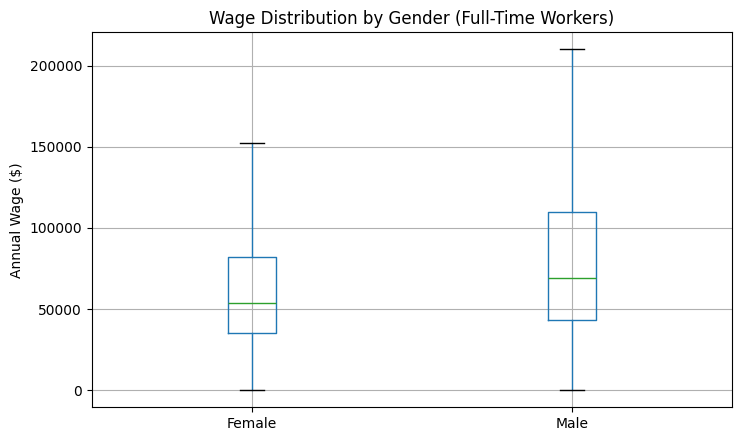

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

df_ft.boxplot(
    column="INCWAGE",
    by="SEX_LABEL",
    ax=ax,
    showfliers=False
)

ax.set_title("Wage Distribution by Gender (Full-Time Workers)")
ax.set_xlabel("")
ax.set_ylabel("Annual Wage ($)")
plt.suptitle("")
plt.show()

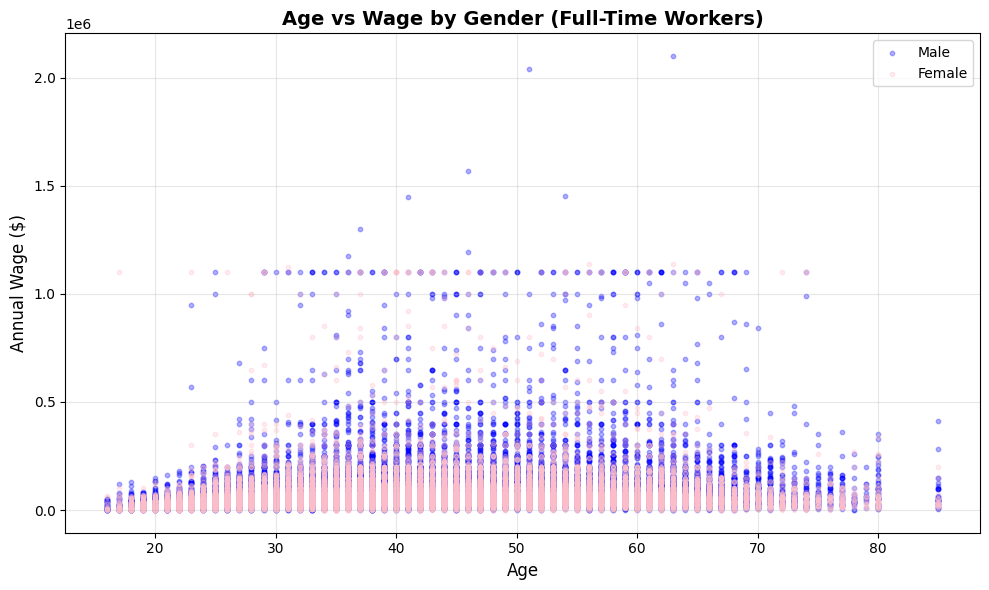

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Male': 'blue', 'Female': 'pink'}

for gender in ['Male', 'Female']:
    subset = df_ft[df_ft['SEX_LABEL'] == gender]
    ax.scatter(subset['AGE'], subset['INCWAGE'],
               alpha=0.3, s=10, label=gender, color=colors[gender])

ax.set_title('Age vs Wage by Gender (Full-Time Workers)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Annual Wage ($)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('../figures/age_wage_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# Gender Wage Gap by State
import seaborn as sns

df_state = df_ft[df_ft['INCWAGE'] > 0].copy()

state_gender_median = df_state.groupby(['STATEFIP', 'SEX_LABEL'])['INCWAGE'].median().unstack()

state_gender_median['Wage_Gap_Percent'] = (
    (state_gender_median['Male'] - state_gender_median['Female']) /
    state_gender_median['Male'] * 100
)

state_sample_size = df_state.groupby('STATEFIP').size()
state_gender_median['Sample_Size'] = state_sample_size

state_gender_median = state_gender_median[state_gender_median['Sample_Size'] >= 30]

state_gender_median_sorted = state_gender_median.sort_values('Wage_Gap_Percent', ascending=False)

print("📊 Top 10 States with Highest Wage Gap:")
print(state_gender_median_sorted[['Male', 'Female', 'Wage_Gap_Percent', 'Sample_Size']].head(10))

print("\n📊 Top 10 States with Lowest Wage Gap:")
print(state_gender_median_sorted[['Male', 'Female', 'Wage_Gap_Percent', 'Sample_Size']].tail(10))

📊 Top 10 States with Highest Wage Gap:
SEX_LABEL      Male    Female  Wage_Gap_Percent  Sample_Size
STATEFIP                                                    
40        60,000.00 41,000.00             31.67          839
29        70,000.00 50,000.00             28.57          728
1         70,000.00 50,000.00             28.57          979
53        84,000.00 60,000.00             28.57          968
30        69,500.00 50,000.00             28.06          797
39        70,000.00 51,000.00             27.14         1216
55        75,000.00 55,000.00             26.67          632
48        68,000.00 50,000.00             26.47         3569
21        60,000.00 44,500.00             25.83          491
26        70,000.00 51,920.00             25.83          988

📊 Top 10 States with Lowest Wage Gap:
SEX_LABEL      Male    Female  Wage_Gap_Percent  Sample_Size
STATEFIP                                                    
19        60,000.00 50,000.00             16.67          651
33     

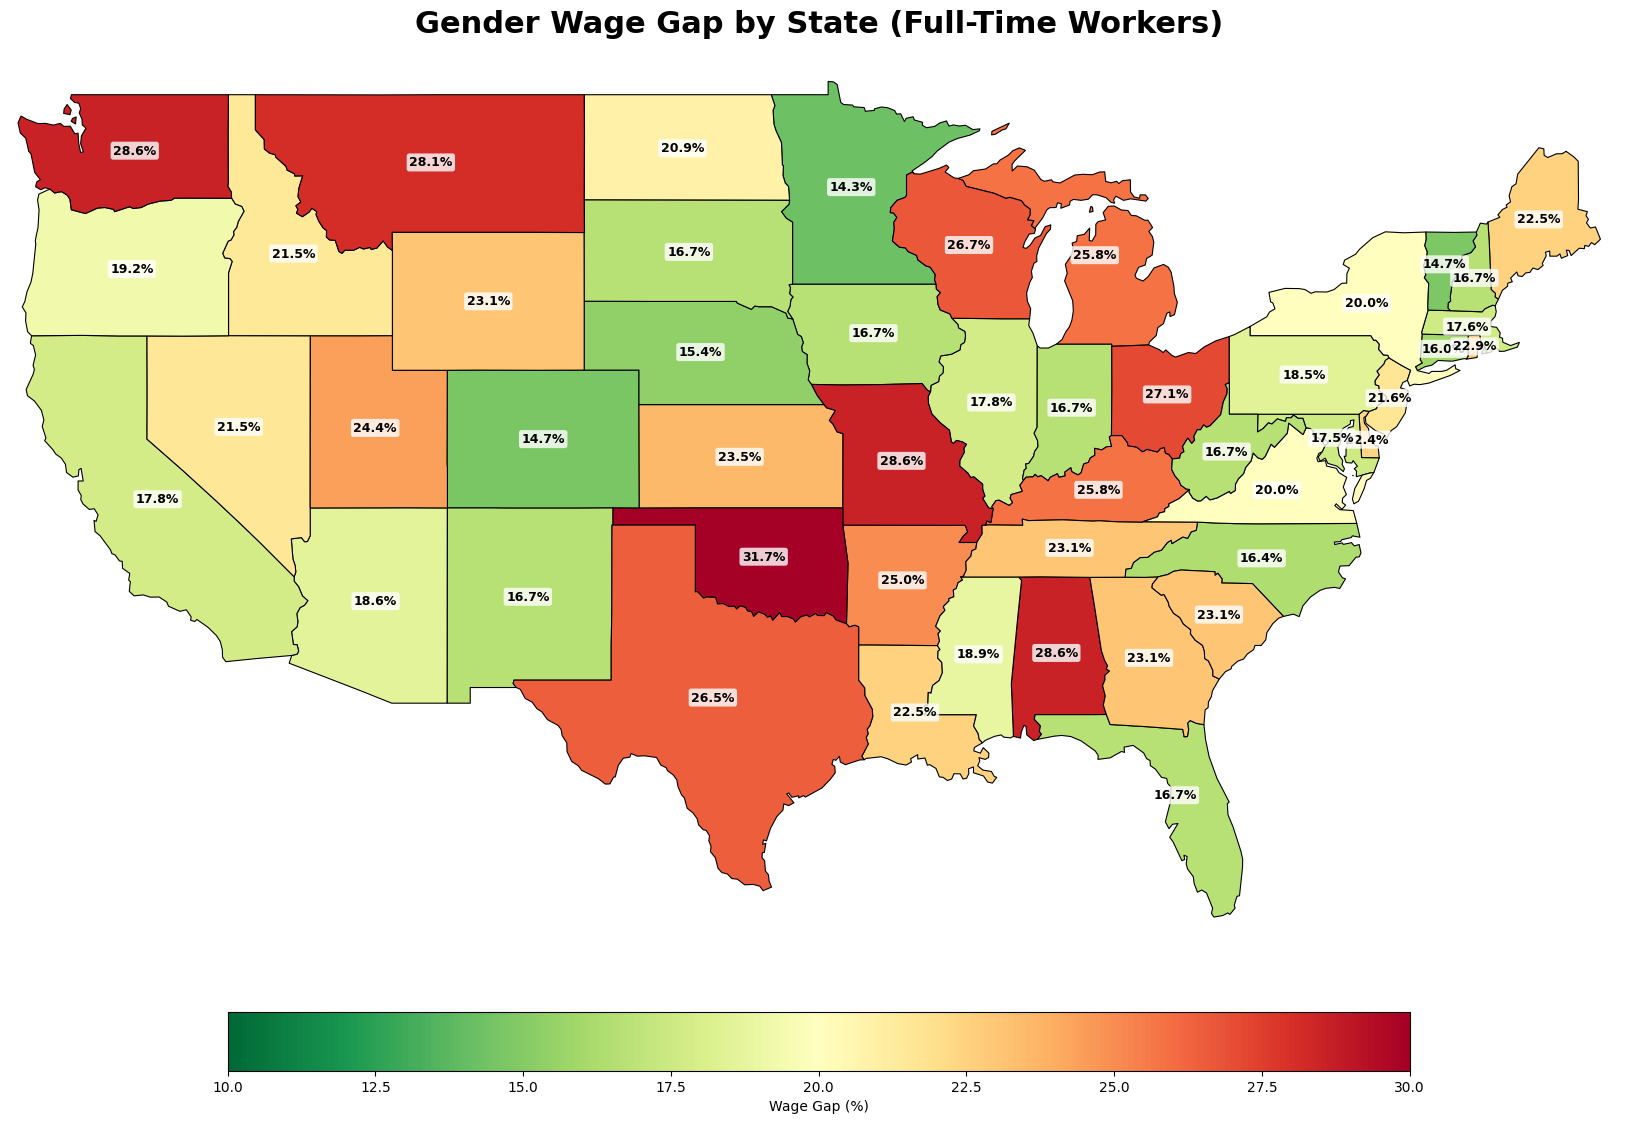

In [33]:
import geopandas as gpd


usa_states = gpd.read_file('https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json')

states_to_remove = ['Hawaii', 'Alaska']
usa_states = usa_states[~usa_states['name'].isin(states_to_remove)]

state_data = state_gender_median.reset_index()
state_data['STATEFIP'] = state_data['STATEFIP'].astype(int)

fips_to_name = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
    12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
    18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
    23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
    27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
    39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania',
    44: 'Rhode Island', 45: 'South Carolina', 46: 'South Dakota',
    47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont',
    51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin',
    56: 'Wyoming'
}
state_data['State_Name'] = state_data['STATEFIP'].map(fips_to_name)

state_data = state_data[~state_data['State_Name'].isin(states_to_remove)]

state_data = state_data.dropna(subset=['Wage_Gap_Percent'])

merged = usa_states.merge(state_data, left_on='name', right_on='State_Name', how='left')

fig, ax = plt.subplots(1, 1, figsize=(20, 12))

merged.plot(
    column='Wage_Gap_Percent',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Wage Gap (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.05
    },
    cmap='RdYlGn_r',
    edgecolor='black',
    linewidth=0.8,
    missing_kwds={'color': 'lightgray', 'label': 'No Data'},
    vmin=10,
    vmax=30
)

ax.set_title('Gender Wage Gap by State (Full-Time Workers)', fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

xlim = (-125, -66)
ylim = (24, 50)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

for idx, row in merged.iterrows():
    if pd.notna(row['Wage_Gap_Percent']):
        centroid = row.geometry.centroid
        if row.geometry.area > 0.01:
            ax.text(
                centroid.x, centroid.y,
                f"{row['Wage_Gap_Percent']:.1f}%",
                fontsize=9,
                ha='center',
                va='center',
                fontweight='bold',
                color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
            )

plt.tight_layout()
# plt.savefig('../figures/state_wage_gap_map.png', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
#Unemployment Rate & Labor Force Participation Rate by gender

df_labor = df[df['AGE'] >= 16].copy()
df_labor = df_labor[df_labor['EMPSTAT'] != 1].copy()
df_labor = df_labor[df_labor['EMPSTAT'] != 0].copy()

df_labor['EMPLOYED'] = df_labor['EMPSTAT'].isin([10, 12]).astype(int)
df_labor['UNEMPLOYED'] = df_labor['EMPSTAT'].isin([20, 21, 22]).astype(int)
df_labor['LABOR_FORCE'] = df_labor['EMPLOYED'] | df_labor['UNEMPLOYED']
df_labor['NILF'] = df_labor['EMPSTAT'].isin([30, 31, 32, 33, 34, 35, 36]).astype(int)


def calculate_labor_stats(df, weight_col='ASECWT'):
    total_population = df[weight_col].sum()

    employed_weight = df[df['EMPLOYED'] == 1][weight_col].sum()

    unemployed_weight = df[df['UNEMPLOYED'] == 1][weight_col].sum()

    labor_force_weight = employed_weight + unemployed_weight

    nilf_weight = df[df['NILF'] == 1][weight_col].sum()

    unemployment_rate = (unemployed_weight / labor_force_weight) * 100
    participation_rate = (labor_force_weight / total_population) * 100

    return {
        'total_population': total_population,
        'employed': employed_weight,
        'unemployed': unemployed_weight,
        'labor_force': labor_force_weight,
        'nilf': nilf_weight,
        'unemployment_rate': unemployment_rate,
        'participation_rate': participation_rate
    }

stats_total = calculate_labor_stats(df_labor)

print("=" * 60)
print("📊 LABOR MARKET STATISTICS (Weighted using ASECWT)")
print("=" * 60)
print(f"\n👥 Total Population (16+): {stats_total['total_population']:,.0f}")
print(f"💼 Employed: {stats_total['employed']:,.0f}")
print(f"🔍 Unemployed: {stats_total['unemployed']:,.0f}")
print(f"⚡ Labor Force: {stats_total['labor_force']:,.0f}")
print(f"🚫 Not in Labor Force: {stats_total['nilf']:,.0f}")
print(f"\n📈 Unemployment Rate: {stats_total['unemployment_rate']:.2f}%")
print(f"📈 Labor Force Participation Rate: {stats_total['participation_rate']:.2f}%")


def calculate_labor_stats_by_gender(df, gender_col='SEX_LABEL', weight_col='ASECWT'):

    results = {}

    for gender in df[gender_col].unique():
        df_gender = df[df[gender_col] == gender]
        stats = calculate_labor_stats(df_gender, weight_col)
        results[gender] = stats

    return results

stats_by_gender = calculate_labor_stats_by_gender(df_labor)

print("\n" + "=" * 60)
print("📊 LABOR MARKET STATISTICS BY GENDER")
print("=" * 60)

for gender, stats in stats_by_gender.items():
    print(f"\n👤 {gender}:")
    print(f"   Population: {stats['total_population']:,.0f}")
    print(f"   Employed: {stats['employed']:,.0f}")
    print(f"   Unemployed: {stats['unemployed']:,.0f}")
    print(f"   Labor Force: {stats['labor_force']:,.0f}")
    print(f"   Unemployment Rate: {stats['unemployment_rate']:.2f}%")
    print(f"   Participation Rate: {stats['participation_rate']:.2f}%")


print("\n" + "=" * 60)
print("📊 GENDER GAPS IN LABOR MARKET INDICATORS")
print("=" * 60)

male_stats = stats_by_gender['Male']
female_stats = stats_by_gender['Female']

unemployment_gap = female_stats['unemployment_rate'] - male_stats['unemployment_rate']
participation_gap = female_stats['participation_rate'] - male_stats['participation_rate']

print(f"\n🔍 Unemployment Rate Gap (Female - Male): {unemployment_gap:+.2f} percentage points")
print(f"📈 Participation Rate Gap (Female - Male): {participation_gap:+.2f} percentage points")

results_df = pd.DataFrame({
    'Gender': ['Total', 'Male', 'Female'],
    'Population': [
        stats_total['total_population'],
        male_stats['total_population'],
        female_stats['total_population']
    ],
    'Employed': [
        stats_total['employed'],
        male_stats['employed'],
        female_stats['employed']
    ],
    'Unemployed': [
        stats_total['unemployed'],
        male_stats['unemployed'],
        female_stats['unemployed']
    ],
    'Labor_Force': [
        stats_total['labor_force'],
        male_stats['labor_force'],
        female_stats['labor_force']
    ],
    'Unemployment_Rate': [
        stats_total['unemployment_rate'],
        male_stats['unemployment_rate'],
        female_stats['unemployment_rate']
    ],
    'Participation_Rate': [
        stats_total['participation_rate'],
        male_stats['participation_rate'],
        female_stats['participation_rate']
    ]
})

print("\n📊 Summary Table:")
print(results_df.round(2).to_string(index=False))

# results_df.to_csv('../reports/labor_stats.csv', index=False)

📊 LABOR MARKET STATISTICS (Weighted using ASECWT)

👥 Total Population (16+): 273,022,688
💼 Employed: 163,184,380
🔍 Unemployed: 7,326,023
⚡ Labor Force: 170,510,403
🚫 Not in Labor Force: 102,512,285

📈 Unemployment Rate: 4.30%
📈 Labor Force Participation Rate: 62.45%

📊 LABOR MARKET STATISTICS BY GENDER

👤 Male:
   Population: 133,175,127
   Employed: 85,795,119
   Unemployed: 4,160,014
   Labor Force: 89,955,133
   Unemployment Rate: 4.62%
   Participation Rate: 67.55%

👤 Female:
   Population: 139,847,561
   Employed: 77,389,261
   Unemployed: 3,166,009
   Labor Force: 80,555,270
   Unemployment Rate: 3.93%
   Participation Rate: 57.60%

📊 GENDER GAPS IN LABOR MARKET INDICATORS

🔍 Unemployment Rate Gap (Female - Male): -0.69 percentage points
📈 Participation Rate Gap (Female - Male): -9.94 percentage points

📊 Summary Table:
Gender     Population       Employed   Unemployed    Labor_Force  Unemployment_Rate  Participation_Rate
 Total 273,022,688.39 163,184,380.19 7,326,023.08 170,510,

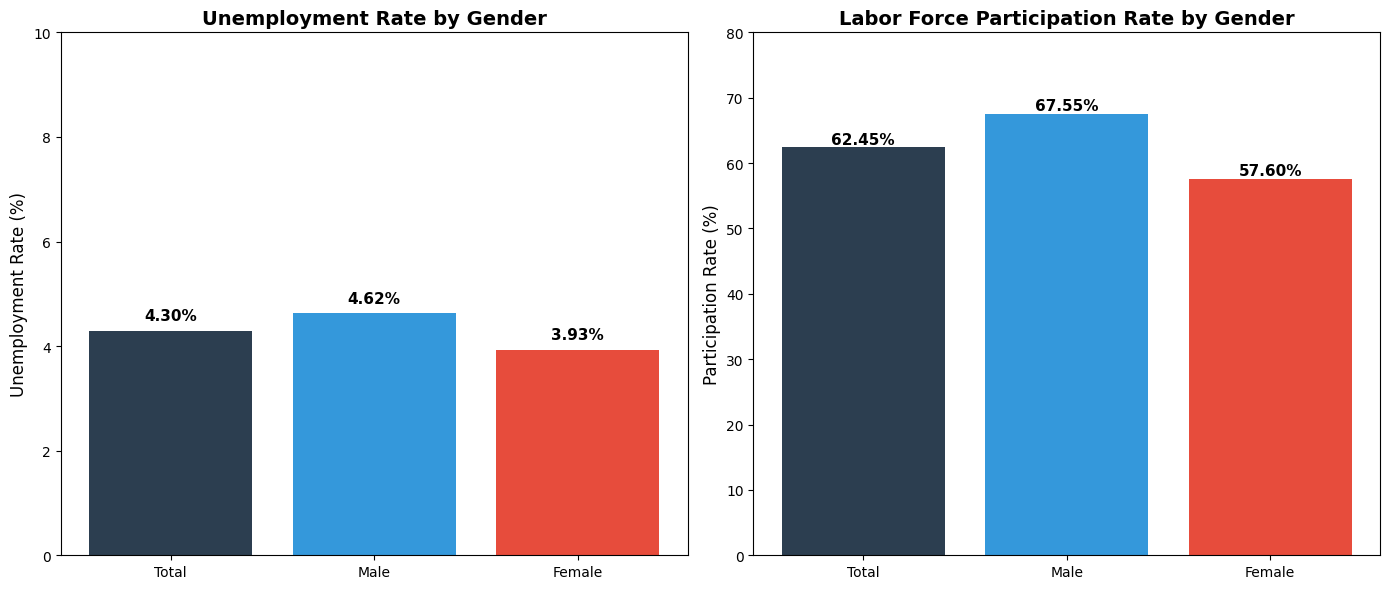

In [40]:
# Visualization of Labor Market Rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


bars1 = ax1.bar(
    results_df['Gender'],
    results_df['Unemployment_Rate'],
    color=['#2c3e50', '#3498db', '#e74c3c']
)
ax1.set_title('Unemployment Rate by Gender', fontsize=14, fontweight='bold')
ax1.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax1.set_ylim(0, 10)

for bar, rate in zip(bars1, results_df['Unemployment_Rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')


bars2 = ax2.bar(
    results_df['Gender'],
    results_df['Participation_Rate'],
    color=['#2c3e50', '#3498db', '#e74c3c']
)
ax2.set_title('Labor Force Participation Rate by Gender', fontsize=14, fontweight='bold')
ax2.set_ylabel('Participation Rate (%)', fontsize=12)
ax2.set_ylim(0, 80)

for bar, rate in zip(bars2, results_df['Participation_Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
# plt.savefig('../figures/labor_rates_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

## Controlled gender wage gap (regression)

In [34]:
import statsmodels.formula.api as smf

formula = ("np.log(INCWAGE) ~ AGE + EDUC + UHRSWORKT + WKSWORK1 "
           "+ C(OCC) + C(IND) + C(CLASSWKR) + C(MARST) + C(SEX) + C(STATEFIP)")
model_full = smf.wls(formula, data=df_ft, weights=df_ft["ASECWT"]).fit()
print(model_full.summary())


                            WLS Regression Results                            
Dep. Variable:        np.log(INCWAGE)   R-squared:                       0.474
Model:                            WLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     55.47
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:39:43   Log-Likelihood:                -55950.
No. Observations:               52883   AIC:                         1.136e+05
Df Residuals:                   52036   BIC:                         1.211e+05
Df Model:                         846                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             8.2256      0.07

In [35]:
female_coef = model_full.params["C(SEX)[T.2]"]
controlled_gap = (np.exp(female_coef) - 1) * 100
print(f"Controlled gender wage gap (women vs. men, other factors held constant): {controlled_gap:.1f}%")


Controlled gender wage gap (women vs. men, other factors held constant): -15.5%


In [36]:
top_factors = (model_full.params / model_full.bse).abs().sort_values(ascending=False).head(10)
print("Top 10 factors by standardized coefficient:")
top_factors


Top 10 factors by standardized coefficient:


,0
Intercept,103.57
WKSWORK1,95.86
EDUC,47.41
C(MARST)[T.6],28.01
C(SEX)[T.2],25.22
C(OCC)[T.4220],25.09
C(OCC)[T.5240],24.64
C(OCC)[T.4720],24.63
C(OCC)[T.2545],24.25
C(OCC)[T.9620],24.16
